Hero-Chart 3 (H4): Politisches Rebranding statt Buzzword-Inflation.

Zentrale Aussage: Programme behalten ihren Kern, wechseln aber das Label
beim Regierungswechsel. Hightech-Strategie (Merkel) verschwindet, Zukunfts-
strategie (Ampel) tritt an deren Stelle - bei vergleichbarem Volumen.

Output: figures/h4_rebranding.png + .pdf

Gespeichert: figures/h4_rebranding.png
Gespeichert: figures/h4_rebranding.pdf


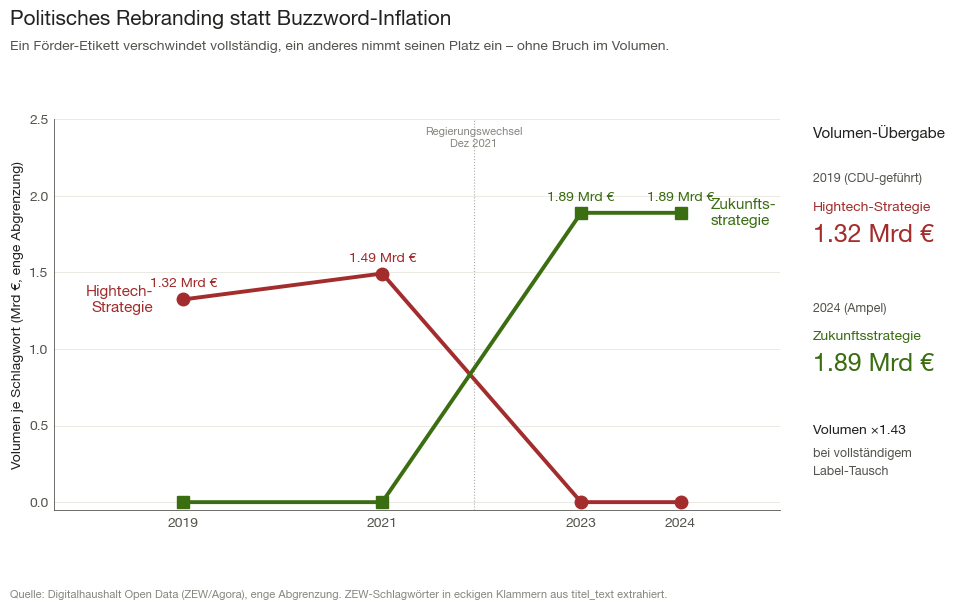

In [1]:
import sys
import re
from pathlib import Path
_root = (
    Path(__file__).parent.parent if '__file__' in globals() else
    next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'src').exists())
)
sys.path.insert(0, str(_root))
__import__('os').chdir(_root)

import matplotlib.pyplot as plt
from src.load import load
from src.style import apply_style, COLORS, add_quelle

apply_style()
df = load('data/raw/Digitalhaushalt_Open_Data.xlsx')


def clean_tag(s):
    s = re.sub(r'\{|\}', '', s).strip().lower()
    return re.sub(r'\s+', ' ', s)


def extract_tags(text):
    if not isinstance(text, str):
        return []
    return [clean_tag(t) for t in re.findall(r'\[([^\]]+)\]', text)]


df['tags'] = df['titel_text'].apply(extract_tags)

# Volumen je Jahr fuer beide Begriffe
def vol_pro_jahr(tag):
    has = df['tags'].apply(lambda lst, t=tag: t in lst)
    return {j: df[has & (df['jahr'] == j)]['digi_soll_eng'].sum() / 1e6
            for j in sorted(df['jahr'].unique())}


hightech = vol_pro_jahr('hightech-strategie')
zukunft = vol_pro_jahr('zukunftsstrategie')

jahre = sorted(hightech.keys())
ht_v = [hightech[j] for j in jahre]
zu_v = [zukunft[j] for j in jahre]

# Plot
fig, ax = plt.subplots(figsize=(11, 6.3))
fig.subplots_adjust(left=0.08, right=0.74, top=0.78, bottom=0.16)

# Hintergrund: Regierungswechsel-Markierung Dez 2021
# Vertikale Linie als visueller Marker
ax.axvline(2021.92, color=COLORS['text_tertiary'], linewidth=0.8,
           linestyle=':', alpha=0.7, zorder=1)
ax.text(2021.92, 2.32, 'Regierungswechsel\nDez 2021', fontsize=8,
        color=COLORS['text_tertiary'], ha='center', style='italic')

# Hightech-Linie (faellt)
ax.plot(jahre, ht_v, color=COLORS['rueckgang'], linewidth=2.8,
        marker='o', markersize=9, zorder=3)
# Zukunfts-Linie (steigt)
ax.plot(jahre, zu_v, color=COLORS['aufstieg'], linewidth=2.8,
        marker='s', markersize=9, zorder=3)

# Endpunkt-Beschriftungen (nur fuer Punkte mit Volumen > 50 Mio)
for j_idx, j in enumerate(jahre):
    if ht_v[j_idx] > 0.05:
        ax.text(j, ht_v[j_idx] + 0.08, f'{ht_v[j_idx]:.2f} Mrd €',
                ha='center', fontsize=10, color=COLORS['rueckgang'], weight='medium')
    if zu_v[j_idx] > 0.05:
        ax.text(j, zu_v[j_idx] + 0.08, f'{zu_v[j_idx]:.2f} Mrd €',
                ha='center', fontsize=10, color=COLORS['aufstieg'], weight='medium')

# Direkte Linien-Labels - links an Start-Punkt, rechts an End-Punkt
ax.text(2018.7, ht_v[0], 'Hightech-\nStrategie',
        ha='right', va='center', fontsize=11,
        color=COLORS['rueckgang'], weight='medium')
ax.text(2024.3, zu_v[-1], 'Zukunfts-\nstrategie',
        ha='left', va='center', fontsize=11,
        color=COLORS['aufstieg'], weight='medium')

# Achsen
ax.set_xticks(jahre)
ax.set_xticklabels([str(j) for j in jahre])
ax.set_xlim(2017.7, 2025.0)
ax.set_ylim(-0.05, 2.5)
ax.set_ylabel('Volumen je Schlagwort (Mrd €, enge Abgrenzung)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.1f}'))

# Titel
fig.text(0.04, 0.93,
         'Politisches Rebranding statt Buzzword-Inflation',
         fontsize=15, weight='medium', color=COLORS['text'])
fig.text(0.04, 0.89,
         'Ein Förder-Etikett verschwindet vollständig, ein anderes nimmt seinen Platz ein – ohne Bruch im Volumen.',
         fontsize=10, color=COLORS['text_secondary'])

# Rechte Spalte: Volumen-Uebergabe
fig.text(0.77, 0.75, 'Volumen-Übergabe',
         fontsize=11, color=COLORS['text'], weight='medium')

fig.text(0.77, 0.68, '2019 (CDU-geführt)',
         fontsize=9, color=COLORS['text_secondary'])
fig.text(0.77, 0.635, 'Hightech-Strategie',
         fontsize=10, color=COLORS['rueckgang'])
fig.text(0.77, 0.585, f'{ht_v[0]:.2f} Mrd €',
         fontsize=18, color=COLORS['rueckgang'], weight='bold')

fig.text(0.77, 0.475, '2024 (Ampel)',
         fontsize=9, color=COLORS['text_secondary'])
fig.text(0.77, 0.430, 'Zukunftsstrategie',
         fontsize=10, color=COLORS['aufstieg'])
fig.text(0.77, 0.380, f'{zu_v[-1]:.2f} Mrd €',
         fontsize=18, color=COLORS['aufstieg'], weight='bold')

fig.text(0.77, 0.28, f'Volumen ×{zu_v[-1]/ht_v[0]:.2f}',
         fontsize=10, color=COLORS['text'], weight='medium')
fig.text(0.77, 0.245, 'bei vollständigem',
         fontsize=9, color=COLORS['text_secondary'])
fig.text(0.77, 0.215, 'Label-Tausch',
         fontsize=9, color=COLORS['text_secondary'])

fig.text(0.04, 0.02,
         'Quelle: Digitalhaushalt Open Data (ZEW/Agora), enge Abgrenzung. '
         'ZEW-Schlagwörter in eckigen Klammern aus titel_text extrahiert.',
         fontsize=8, color=COLORS['text_tertiary'], style='italic')

# Speichern
out_dir = Path('figures')
out_dir.mkdir(exist_ok=True)
fig.savefig(out_dir / 'h4_rebranding.png', dpi=200)
fig.savefig(out_dir / 'h4_rebranding.pdf')
print(f"Gespeichert: {out_dir/'h4_rebranding.png'}")
print(f"Gespeichert: {out_dir/'h4_rebranding.pdf'}")